In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (10,6)

MY_NAME = "Devarsh Bhatt"

In [4]:
df = pd.read_csv("Smartphone_Usage_And_Addiction_Analysis_7500_Rows-2.csv")

df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [6]:
bins = [15, 25, 35, 50, 100]
labels = ['Youth', 'Young Adults', 'Adults', 'Senior Citizens']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

Question 1

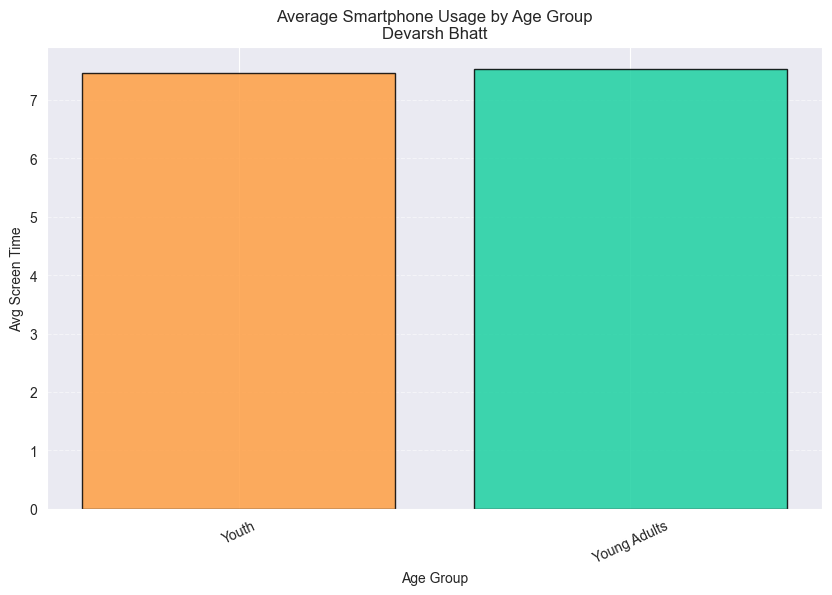

In [8]:
screen_col = [col for col in df.columns if 'screen' in col][0]

avg_usage = df.groupby('age_group')[screen_col].mean()

plt.figure()
plt.bar(avg_usage.index, avg_usage.values,
        color=['#ff9f43','#1dd1a1','#54a0ff','#5f27cd'],
        edgecolor='black', alpha=0.85)

plt.title("Average Smartphone Usage by Age Group\n" + MY_NAME)
plt.xlabel("Age Group")
plt.ylabel("Avg Screen Time")

plt.xticks(rotation=25)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Question 2

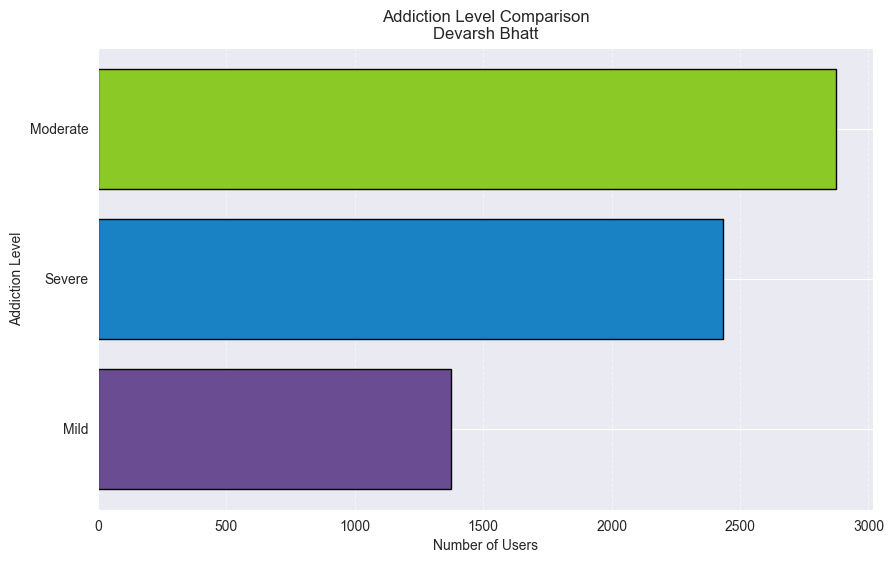

In [14]:
addiction = df['addiction_level'].value_counts().sort_values()

plt.figure()

plt.barh(addiction.index, addiction.values,
         color=['#6a4c93','#1982c4','#8ac926','#ffca3a','#ff595e'],
         edgecolor='black')

plt.title("Addiction Level Comparison\n" + MY_NAME)
plt.xlabel("Number of Users")
plt.ylabel("Addiction Level")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

Question 3

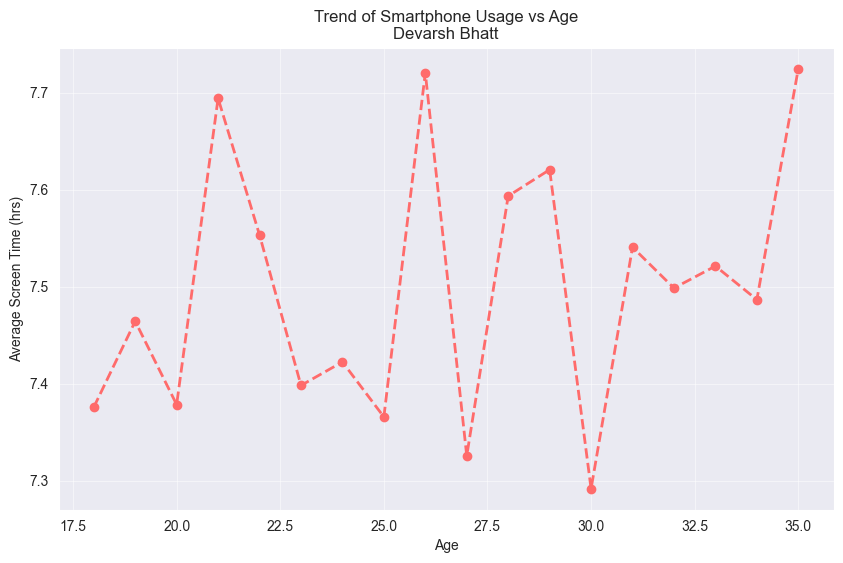

In [15]:
trend = df.groupby('age')['daily_screen_time_hours'].mean()

plt.figure()

plt.plot(trend.index, trend.values,
         marker='o', linestyle='--', linewidth=2, color='#ff6b6b')

plt.title("Trend of Smartphone Usage vs Age\n" + MY_NAME)
plt.xlabel("Age")
plt.ylabel("Average Screen Time (hrs)")

plt.grid(alpha=0.5)

plt.show()

Question 4

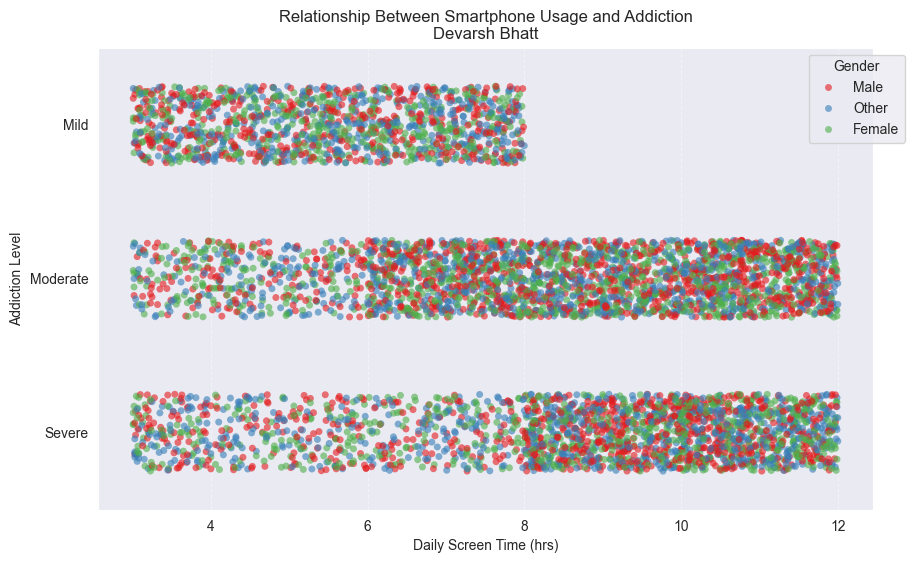

In [17]:
plt.figure(figsize=(10,6))

sns.stripplot(
    data=df,
    x='daily_screen_time_hours',
    y='addiction_level',
    hue='gender',
    jitter=0.25,
    alpha=0.6,
    palette='Set1'
)

plt.title("Relationship Between Smartphone Usage and Addiction\n" + MY_NAME)
plt.xlabel("Daily Screen Time (hrs)")
plt.ylabel("Addiction Level")

plt.legend(title='Gender', bbox_to_anchor=(1.05,1))
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

Question 5

C:\Users\Devarsh\AppData\Local\Temp\ipykernel_24316\2322078072.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


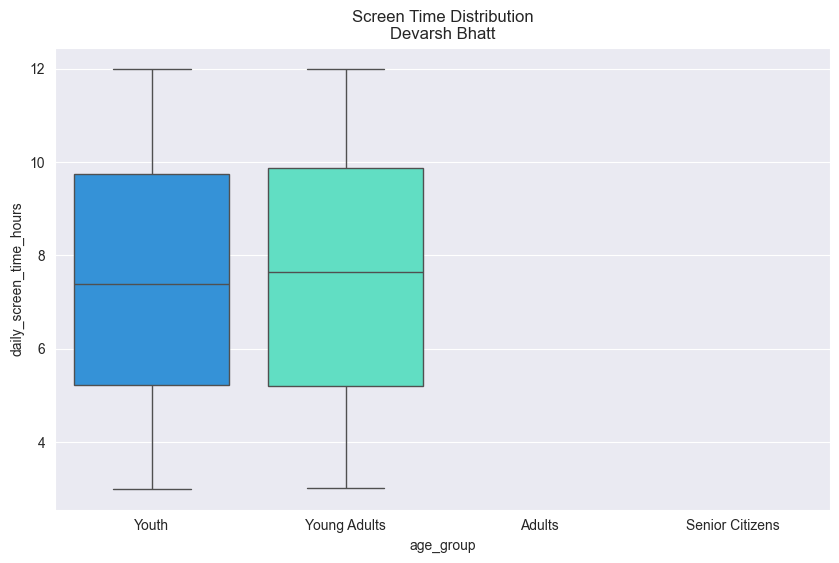

In [32]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='age_group',
    y='daily_screen_time_hours',
    palette='rainbow'
)

plt.title("Screen Time Distribution\n" + MY_NAME)

plt.show()

Question 6

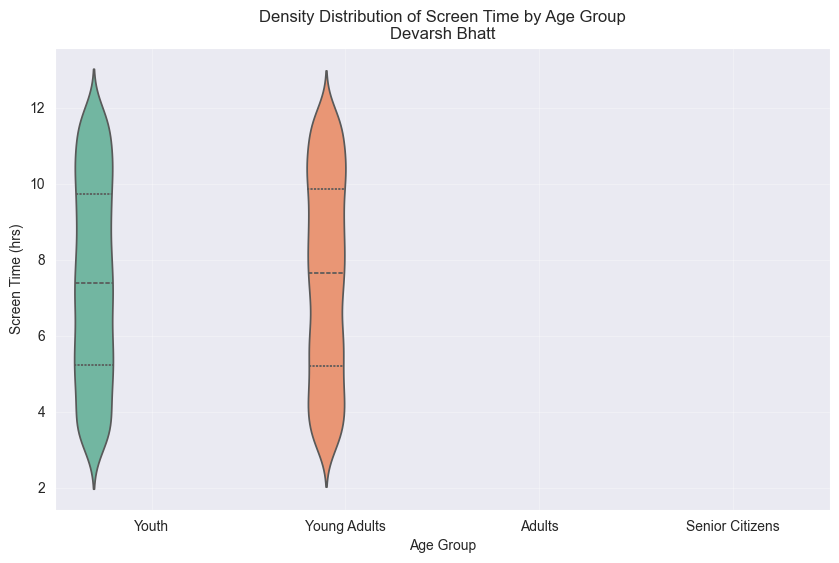

In [35]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='age_group',
    y='daily_screen_time_hours',
    hue='age_group',
    palette='Set2',
    legend=False,
    inner='quartile'   
)

plt.title("Density Distribution of Screen Time by Age Group\n" + MY_NAME)
plt.xlabel("Age Group")
plt.ylabel("Screen Time (hrs)")

plt.grid(alpha=0.3)
plt.show()

Question 7

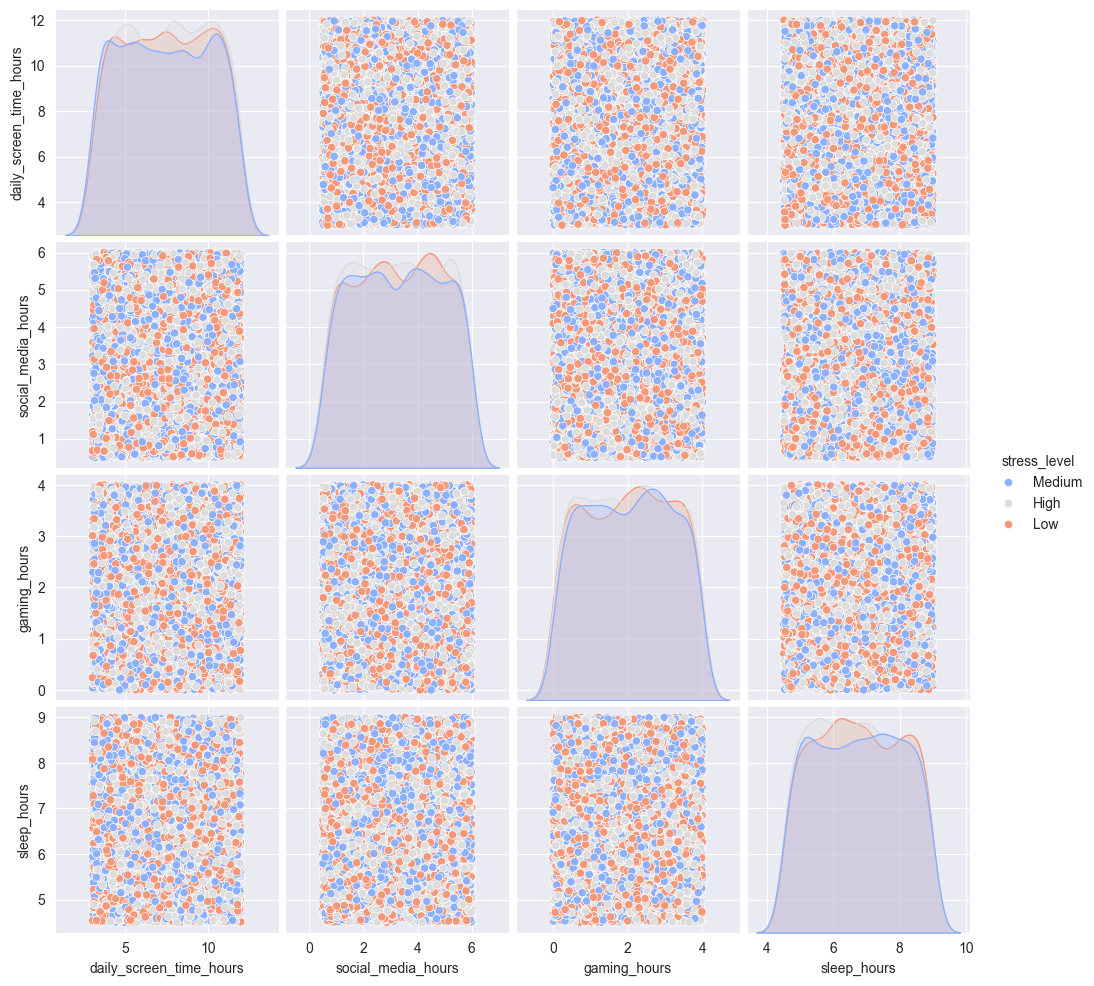

In [36]:
sns.pairplot(
    df[['daily_screen_time_hours',
        'social_media_hours',
        'gaming_hours',
        'sleep_hours',
        'stress_level']],
    hue='stress_level',
    palette='coolwarm',
    diag_kind='kde'
)

Question 8

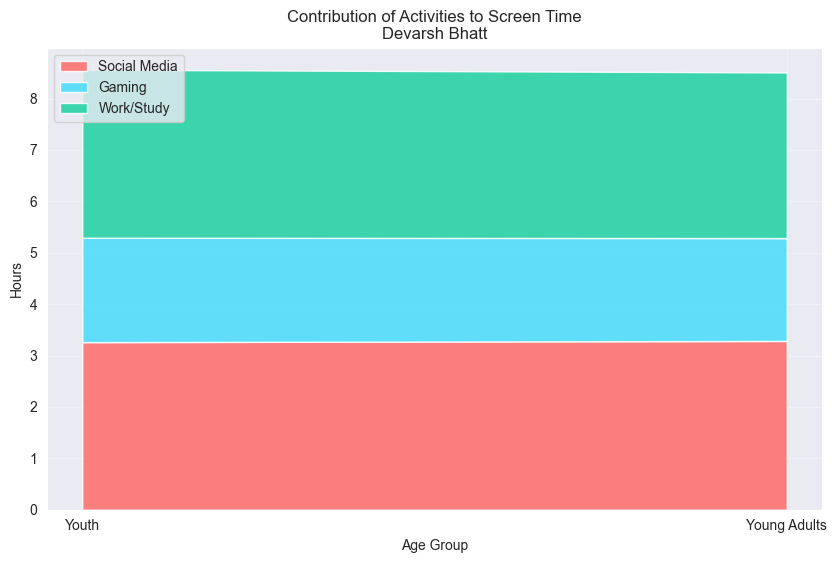

In [37]:
group = df.groupby('age_group')[[
    'social_media_hours',
    'gaming_hours',
    'work_study_hours'
]].mean()

x = range(len(group))

plt.figure(figsize=(10,6))

plt.stackplot(
    x,
    group['social_media_hours'],
    group['gaming_hours'],
    group['work_study_hours'],
    labels=['Social Media', 'Gaming', 'Work/Study'],
    colors=['#ff6b6b','#48dbfb','#1dd1a1'],
    alpha=0.85
)

plt.xticks(x, group.index)

plt.title("Contribution of Activities to Screen Time\n" + MY_NAME)
plt.xlabel("Age Group")
plt.ylabel("Hours")

plt.legend(loc='upper left')
plt.grid(alpha=0.3)

plt.show()

Question 9

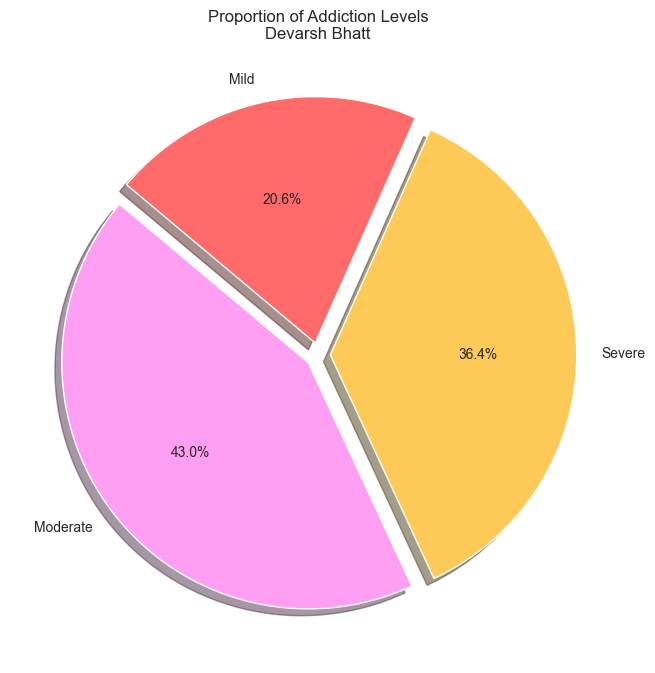

In [38]:
pie = df['addiction_level'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    pie.values,
    labels=pie.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#ff9ff3','#feca57','#ff6b6b'],
    explode=[0.05]*len(pie),
    shadow=True
)

plt.title("Proportion of Addiction Levels\n" + MY_NAME)

plt.show()

Question 10

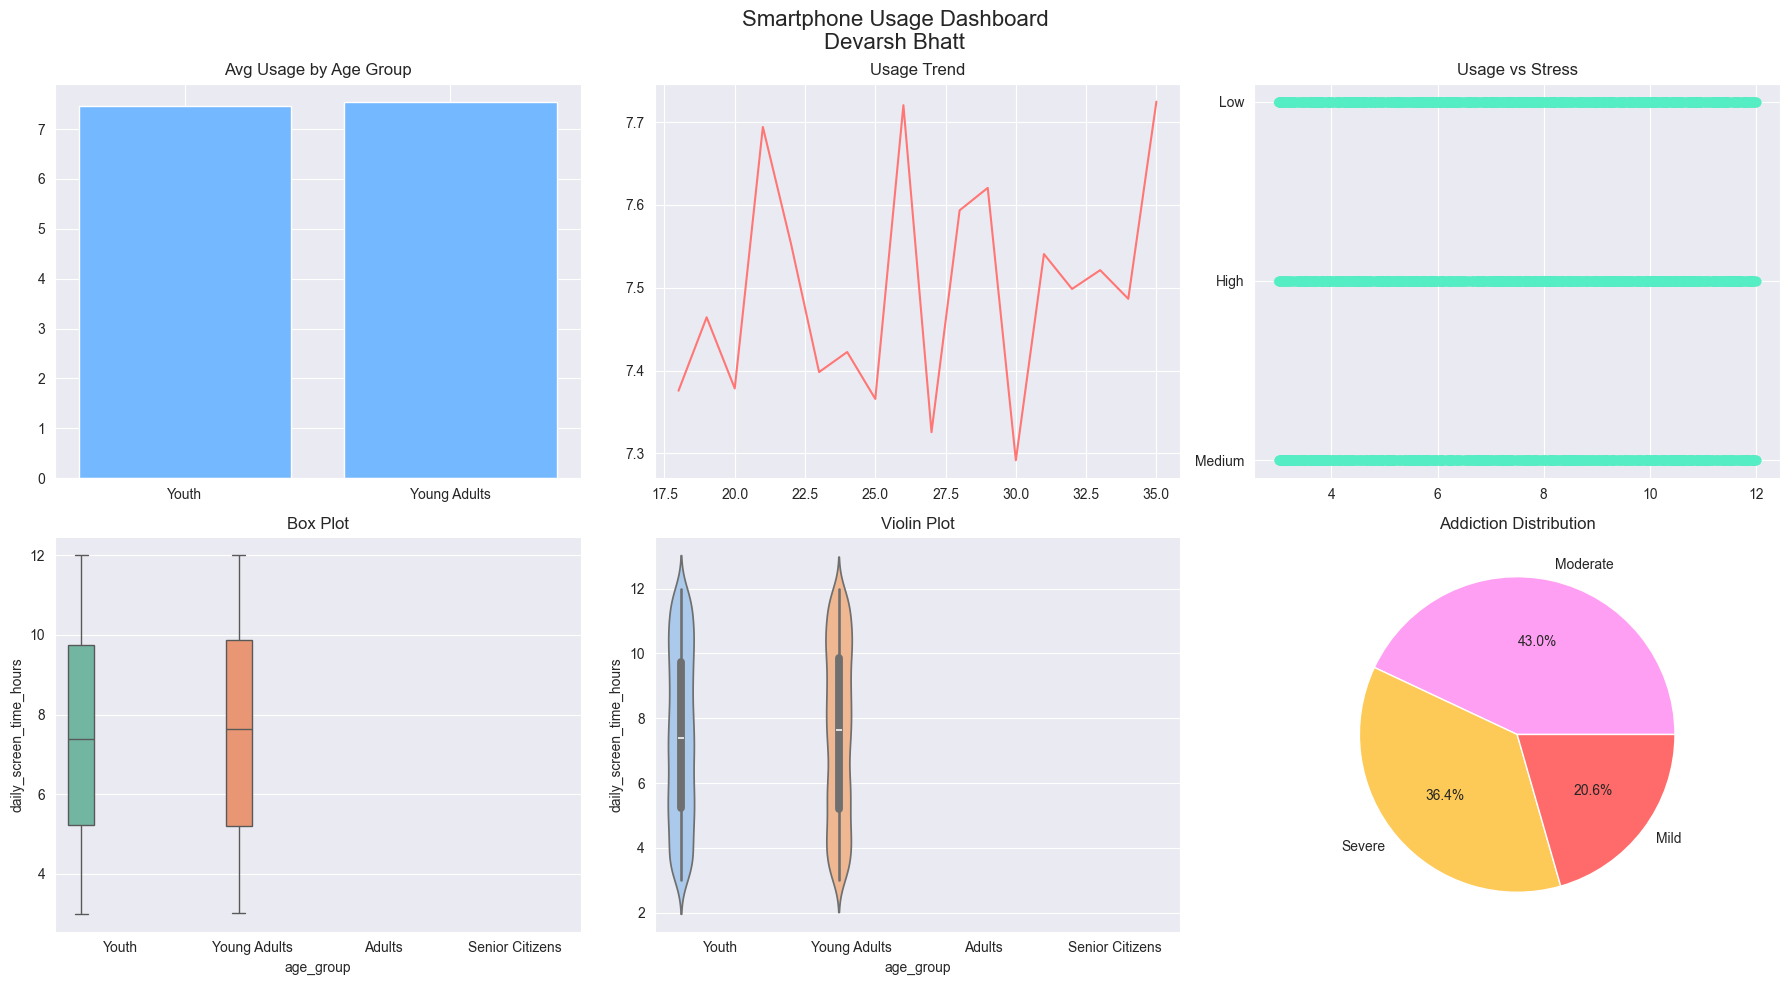

In [43]:
fig, axs = plt.subplots(2, 3, figsize=(18,10))

avg_usage = df.groupby('age_group')['daily_screen_time_hours'].mean()
axs[0,0].bar(avg_usage.index, avg_usage.values, color='#74b9ff')
axs[0,0].set_title("Avg Usage by Age Group")

trend = df.groupby('age')['daily_screen_time_hours'].mean()
axs[0,1].plot(trend.index, trend.values, color='#ff7675')
axs[0,1].set_title("Usage Trend")

axs[0,2].scatter(df['daily_screen_time_hours'], df['stress_level'],
                 color='#55efc4', alpha=0.5)
axs[0,2].set_title("Usage vs Stress")

sns.boxplot(
    data=df,
    x='age_group',
    y='daily_screen_time_hours',
    hue='age_group',
    palette='Set2',
    legend=False,
    ax=axs[1,0]
)
axs[1,0].set_title("Box Plot")

sns.violinplot(
    data=df,
    x='age_group',
    y='daily_screen_time_hours',
    hue='age_group',
    palette='pastel',
    legend=False,
    ax=axs[1,1]
)
axs[1,1].set_title("Violin Plot")

pie = df['addiction_level'].value_counts()
axs[1,2].pie(
    pie.values,
    labels=pie.index,
    autopct='%1.1f%%',
    colors=['#ff9ff3','#feca57','#ff6b6b']
)
axs[1,2].set_title("Addiction Distribution")

fig.suptitle("Smartphone Usage Dashboard\n" + MY_NAME, fontsize=16)

plt.tight_layout()
plt.show()